# IDENTITAS DIRI
Nama : Muhammad Rayhan Zamzami

NIM : 244107020027

Kelas : TI-3G

Absen : 19

In [9]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/ml-semester5/dataset/diabetes_012_health_indicators_BRFSS2015.csv')

df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [11]:
# Cek data awal
print("Tipe data tiap kolom:")
print(df.dtypes.value_counts())

print("\nTotal missing value per kolom (hanya yang > 0):")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing value")

print(f"\nJumlah baris duplikat: {df.duplicated().sum()}")

print("\nSebaran kelas Diabetes_012 (0=tidak, 1=pra-diabetes, 2=diabetes):")
print(df['Diabetes_012'].value_counts().sort_index())

Tipe data tiap kolom:
float64    22
Name: count, dtype: int64

Total missing value per kolom (hanya yang > 0):
Tidak ada missing value

Jumlah baris duplikat: 23899

Sebaran kelas Diabetes_012 (0=tidak, 1=pra-diabetes, 2=diabetes):
Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64


In [13]:
# Preprocessing
df_raw = df.copy()
df = df_raw.copy()
n_awal = len(df)

# Buang kelas 1 (pra-diabetes), fokus ke diabetes vs tidak
df = df[df['Diabetes_012'] != 1]
print(f"Setelah buang kelas 1      : {len(df)} baris (terbuang {n_awal - len(df)})")  # laporan jumlah baris setelah kelas 1 dibuang

# Membuang kolom income
df = df.drop(columns=['Income'])
print(f"Setelah buang kolom Income : {df.shape[1]} kolom")

# Menghapus baris duplikat
n_sebelum_dup = len(df)
df = df.drop_duplicates()
print(f"Setelah hapus duplikat     : {len(df)} baris (terbuang {n_sebelum_dup - len(df)})")

# Rapikan nomor baris jadi 0,1,2,... lagi
df = df.reset_index(drop=True)

# Pisahkan tabel fitur dan label
y_label = df['Diabetes_012'].copy()
df_features = df.drop(columns=['Diabetes_012']).astype(float)
print(f"Jumlah fitur untuk klastering: {df_features.shape[1]}")
print(f"Daftar fitur: {list(df_features.columns)}")

# Standardisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)
print(f"Bentuk data siap klaster: {X_scaled.shape}")
print(f"Cek mean 0 dan std 1: {X_scaled.mean():.4f} / {X_scaled.std():.4f}")
df_features.head()

Setelah buang kelas 1      : 249049 baris (terbuang 4631)
Setelah buang kolom Income : 21 kolom
Setelah hapus duplikat     : 208858 baris (terbuang 40191)
Jumlah fitur untuk klastering: 20
Daftar fitur: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education']
Bentuk data siap klaster: (208858, 20)
Cek mean 0 dan std 1: -0.0000 / 1.0000


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0


In [15]:
# Mengambil sampel data dari hasil preprocessing
sample_size = 10000
np.random.seed(42)

sample_idx = np.random.choice(
    X_scaled.shape[0],
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_idx]
target_sample = y_label.iloc[sample_idx].reset_index(drop=True)

# DBSCAN Manhattan
dbscan = DBSCAN(
    eps=5,
    min_samples=10,
    metric='manhattan',
    n_jobs=-1
)

labels = dbscan.fit_predict(X_sample)
labels

array([-1,  0,  0, ...,  0,  0,  0])

In [17]:
# Menambahkan hasil cluster
df_cluster = pd.DataFrame(
    X_sample,
    columns=df_features.columns
)

df_cluster['Cluster'] = labels
df_cluster['Diabetes_012'] = target_sample

df_cluster.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Cluster,Diabetes_012
0,1.080332,1.113803,-4.696850,-1.276612,-0.948485,-0.224224,-0.349517,-1.598257,0.816731,0.524458,...,-0.331319,0.332470,-0.346646,0.109249,2.018214,-0.888625,1.598272,-2.961535,-1,0.0
1,1.080332,1.113803,0.212909,-0.409641,1.054313,-0.224224,-0.349517,0.625682,-1.224393,0.524458,...,-0.331319,0.332470,-0.473039,-0.538842,2.018214,-0.888625,1.275507,-1.961602,0,0.0
2,1.080332,-0.897825,0.212909,1.757787,-0.948485,-0.224224,-0.349517,0.625682,-1.224393,0.524458,...,-0.331319,-0.602472,3.318747,-0.538842,-0.495488,-0.888625,0.629976,-0.961670,0,0.0
3,-0.925642,-0.897825,0.212909,1.324301,-0.948485,-0.224224,-0.349517,0.625682,-1.224393,0.524458,...,-0.331319,-1.537415,-0.473039,-0.538842,-0.495488,1.125334,-0.661085,1.038195,0,0.0
4,-0.925642,1.113803,0.212909,3.058244,-0.948485,-0.224224,-0.349517,-1.598257,-1.224393,0.524458,...,-0.331319,-1.537415,2.181211,-0.538842,-0.495488,-0.888625,0.307211,0.038263,-1,0.0


In [18]:
# Jumlah data setiap cluster
cluster_counts = df_cluster['Cluster'].value_counts().sort_index()

print(cluster_counts)

# Jumlah cluster tanpa noise
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Jumlah noise
n_noise = list(labels).count(-1)

print("Jumlah Cluster :", n_clusters)
print("Jumlah Noise   :", n_noise)

# Data tanpa noise
mask = labels != -1

X_eval = X_sample[mask]
labels_eval = labels[mask]

# Evaluasi Silhouette Score
if len(set(labels_eval)) > 1:
    silhouette = silhouette_score(
        X_eval,
        labels_eval,
        metric='manhattan'
    )
    print("Silhouette Score (Manhattan):", silhouette)
else:
    print("Silhouette Score tidak dapat dihitung karena cluster kurang dari 2.")

# Evaluasi Davies-Bouldin Index
if len(set(labels_eval)) > 1:
    dbi = davies_bouldin_score(
        X_eval,
        labels_eval
    )
    print("Davies-Bouldin Index:", dbi)
else:
    print("DBI tidak dapat dihitung.")

# Evaluasi Calinski-Harabasz Index
if len(set(labels_eval)) > 1:
    ch = calinski_harabasz_score(
        X_eval,
        labels_eval
    )
    print("Calinski-Harabasz Index:", ch)
else:
    print("CH Index tidak dapat dihitung.")

Cluster
-1    1768
 0    8227
 1       5
Name: count, dtype: int64
Jumlah Cluster : 2
Jumlah Noise   : 1768
Silhouette Score (Manhattan): 0.39509746461975587
Davies-Bouldin Index: 0.925712421050659
Calinski-Harabasz Index: 13.311730111649215


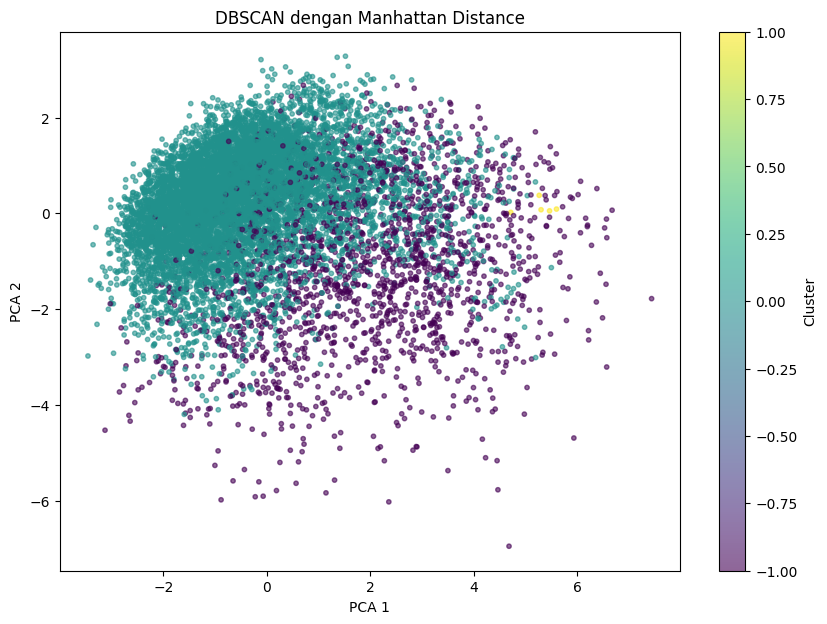

In [19]:
# Reduksi dimensi menjadi 2D
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    s=10,
    alpha=0.6
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('DBSCAN dengan Manhattan Distance')
plt.colorbar(scatter, label='Cluster')

plt.show()

In [20]:
# Simpan hasil clustering
df_cluster.to_csv(
    '/content/drive/MyDrive/ml-semester5/dataset/diabetes_dbscan_manhattan_results.csv',
    index=False
)

print("Hasil berhasil disimpan.")

Hasil berhasil disimpan.
